# Exploratory Data Analysis — Cyber Conflict Incident Datasets

This notebook covers the **statistical / exploratory** part of EDA for the four cleaned datasets:

- `global_dataset_clean.csv` — one row per incident (84 columns, main table)
- `dyadic_dataset_clean.csv` — one row per initiator–receiver dyad within an incident
- `attribution_dataset_clean.csv` — one row per attribution claim
- `receiver_dataset_clean.csv` — one row per receiver (victim) entity

We'll focus most of the numeric/statistical exploration on `global_dataset_clean.csv` since it is
the main incident-level table, and bring in `dyadic_dataset_clean.csv` for a few relationship
questions between initiators/receivers and impact.

**Contents**
1. Load & inspect
2. Missingness overview
3. Descriptive statistics (numeric columns)
4. Distributions (histograms / KDE)
5. Outlier detection (boxplots + IQR/Z-score)
6. Categorical variable frequencies
7. Correlation heatmap
8. Scatterplots between key numeric variables
9. Pairplot of a small, meaningful subset of columns
10. Quick relationship checks across datasets (dyadic)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


## 1. Load & inspect

In [ ]:
global_df = pd.read_csv("global_dataset_clean.csv")
dyadic_df = pd.read_csv("dyadic_dataset_clean.csv")
attribution_df = pd.read_csv("attribution_dataset_clean.csv")
receiver_df = pd.read_csv("receiver_dataset_clean.csv")

for name, df in [("global", global_df), ("dyadic", dyadic_df),
                  ("attribution", attribution_df), ("receiver", receiver_df)]:
    print(f"{name:12s} shape = {df.shape}")


global       shape = (3414, 84)
dyadic       shape = (4296, 51)
attribution  shape = (5188, 16)
receiver     shape = (12180, 6)


In [ ]:
global_df.head()

,incident_id,name,description,start_date,end_date,inclusion_criterion,inclusion_criterion_subcode,source_disclosure,incident_type,receiver_name,receiver_country,receiver_country_alpha_2_code,receiver_regions,receiver_category,receiver_subcategory,initiator_name,initiator_country,initiator_alpha_2,initiator_category,initiator_subcategory,number_attributions,attribution_id,attribution_date,attribution_type,attribution_basis,attributing_actor,attributing_company,attributing_country,settled_initiator,initiator_country.1,initiator_category.1,attribution_source_url,cyber_conflict_issue,offline_conflict_issue,offline_conflict_name,offline_conflict_intensity,offline_conflict_intensity_subcode,number_political_responses,political_response_date,political_response_type,political_response_subtype,political_response_responding_country,political_response_responding_actor,zero_days,mitre_initial_access,mitre_impact,has_disruption,data_theft,disruption,hijacking,physical_effects_spatial,physical_effects_temporal,unweighted_intensity,target_multiplier,weighted_intensity,impact_indicator_label,impact_indicator_score,functional_impact,intelligence_impact,affected_entities,affected_entities_value,affected_third_countries,affected_third_countries_value,economic_impact_value,economic_impact_currency,state_responsibility_actor,il_breach_indicator,il_breach_indicator_subcode,number_legal_responses,legal_response_date,legal_response_type,legal_response_responding_country,legal_response_responding_actor,attribution_legal_reference,attribution_legal_reference_subcode,response_indicator,source_url,added_to_db,updated_at,incident_type_list,receiver_country_list,receiver_category_list,initiator_country_list,cyber_conflict_issue_list
0,4163,Russian State-Sponsored Actors Linked to GRU ...,"On 19 December 2024, a cyber attack attributed...",2024-12-19,2024-12-19,Attack conducted by nation state (generic “sta...,Not available;Not available,Incident disclosed by authorities of victim state,Disruption;Hijacking with Misuse,Ministry of Justice (Ukraine),Ukraine,UA,"['EUROPE', 'EASTEU']",State institutions / political system,Government / ministries,NaN,Russia,RU,State,NaN,1,25486,2024-12-19,"Direct statement in media report (e.g., Reuter...",Attribution by receiver government / state entity,Deputy Prime Minister and Justice Minister Olg...,NaN,Ukraine,True,Russia,State,https://www.facebook.com/olga.kravets.796/post...,International power,Territory;International power,Russia – Ukraine;Russia – Ukraine,Yes / HIIK intensity;Yes / HIIK intensity,HIIK 5;HIIK 5,1,2024-12-19,State Actors: Stabilizing measures,Statement by head of state/head of government ...,Ukraine,Deputy Prime Minister (Olha Stefanishyna) (Ukr...,NaN,NaN,Data Destruction,True,NaN,Long-term disruption (> 24h; incident scores 2...,"Hijacking, system misuse, e.g., through data t...",none,none,4,Moderate - high political importance,4,Low,8,Weeks (< 4 weeks),No data breach/exfiltration or data corruption...,1-10,0,1-10,1,0,euro,Direct (official members of state entities / a...,Armed conflict;Sovereignty,Conduct of hostilities;Not available,1,NaN,Other legal measures on national level (e.g. l...,Ukraine,Security Service of Ukraine (SBU),NaN,NaN,Countermeasures under international law justif...,https://www.t-online.de/nachrichten/ukraine/id...,2024-12-23,2025-02-18,"['Disruption', 'Hijacking with Misuse']",['Ukraine'],['State institutions / political system'],['Russia'],['International power']
1,4161,Unknown threat actors stole Microsoft Azure ac...,Unit 42 researchers uncovered a phishing campa...,2024-06-01,NaN,Attack on critical infrastructure target(s),NaN,Incident disclosed by IT-security company,Data theft;Hijacking with Misuse,Not available;Not available;Not available;Not ...,Germany;Germany;Germany;United Kingdom;United ...,DE;DE;DE;GB;GB;GB;EUROPE;EUROPE;EUROPE,"['EUROPE', 'NATO', 'EU', 'WESTEU'];['EUROPE', ...",Critical infrastructure;Corporate Targets (cor...,Chemicals;Not available;Critical Manuf

In [ ]:
global_df.dtypes.value_counts()

str        72
int64      10
bool        1
float64     1
Name: count, dtype: int64

## 2. Missingness overview

Many columns in this dataset are conditionally populated (e.g. legal-response fields only apply
if a legal response happened), so high missingness in a specific field is often expected rather
than a data-quality problem. Still, it's the first thing to check before any statistical test.

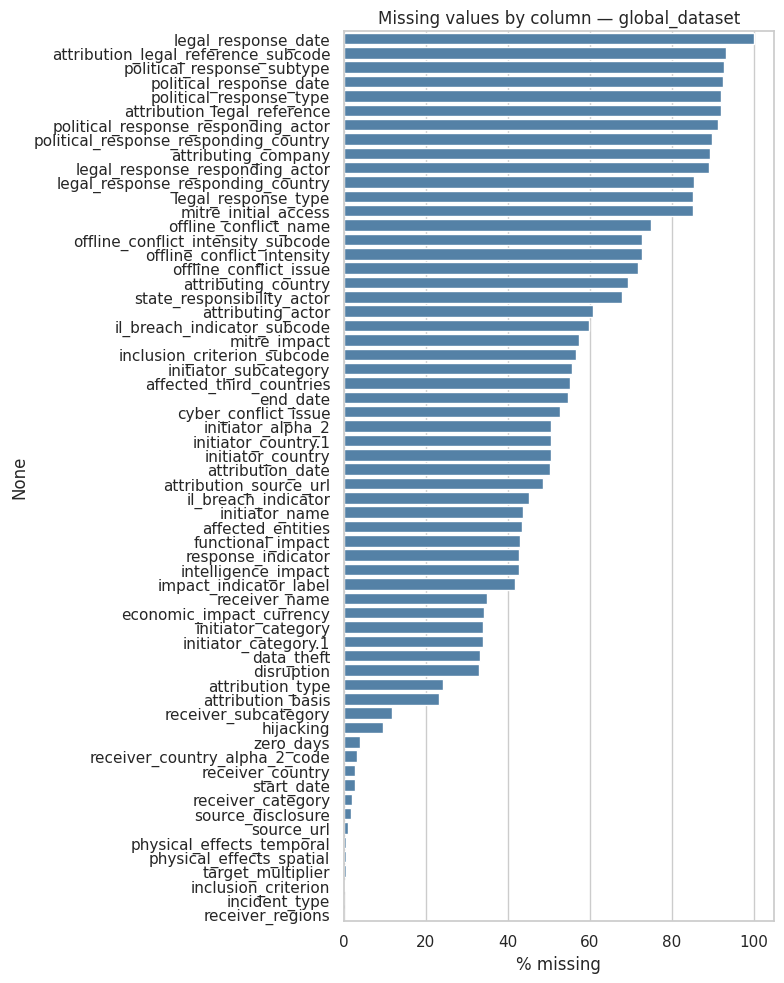

In [ ]:
missing_pct = global_df.isna().mean().sort_values(ascending=False) * 100
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(8, 10))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color="steelblue")
plt.xlabel("% missing")
plt.title("Missing values by column — global_dataset")
plt.tight_layout()
plt.show()


### Understanding the Missing Values Plot
This bar chart shows the percentage of empty (null) data for each column.

**What this means:**
- **X-axis (% missing):** A longer bar means more data is missing for that variable.
- **Variable examples:** `legal_response_date` is often missing because many incidents don't result in a legal response. It doesn't necessarily mean the data is 'bad'; it often means the event simply didn't happen for that specific incident.

## 3. Descriptive statistics (numeric columns)

In [ ]:
numeric_cols = global_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
# drop id-like / date-like / all-missing columns that aren't meaningful to summarize
drop_like = ["incident_id", "legal_response_date"]
numeric_cols = [c for c in numeric_cols if c not in drop_like and global_df[c].notna().any()]
print(numeric_cols)

global_df[numeric_cols].describe().T


['number_attributions', 'number_political_responses', 'unweighted_intensity', 'weighted_intensity', 'impact_indicator_score', 'affected_entities_value', 'affected_third_countries_value', 'economic_impact_value', 'number_legal_responses']


,count,mean,std,min,25%,50%,75%,max
number_attributions,3414.0,1.142941,5.072706e-01,1.0,1.0,1.0,1.0,10.0
number_political_responses,3414.0,0.114821,4.958043e-01,0.0,0.0,0.0,0.0,13.0
unweighted_intensity,3414.0,2.427065,1.353159e+00,0.0,1.0,2.0,3.0,7.0
weighted_intensity,3414.0,2.443175,1.425201e+00,0.0,1.0,2.0,3.0,11.0
impact_indicator_score,3414.0,3.944347,3.606219e+00,0.0,0.0,5.0,7.0,15.0
affected_entities_value,3414.0,297.603105,1.711530e+04,0.0,0.0,0.0,1.0,1000000.0
affected_third_countries_value,3414.0,0.477153,8.771137e-01,0.0,0.0,0.0,1.0,23.0
economic_impact_value,3414.0,857210.881078,1.945574e+07,0.0,0.0,0.0,0.0,872000000.0
number_legal_responses,3414.0,0.153486,3.946513e-01,0.0,0.0,0.0,0.0,3.0


In [ ]:
# Skewness & kurtosis — quick signal for which variables are heavily skewed (common in impact/economic data)
skew_kurt = pd.DataFrame({
    "skew": global_df[numeric_cols].skew(),
    "kurtosis": global_df[numeric_cols].kurtosis()
}).sort_values("skew", ascending=False)
skew_kurt


## 4. Distributions

Histograms with KDE overlay for the key intensity/impact metrics. Economic values and
"affected entities" counts are expected to be extremely right-skewed (a few huge incidents,
many small ones), so we also look at a log-scale version.

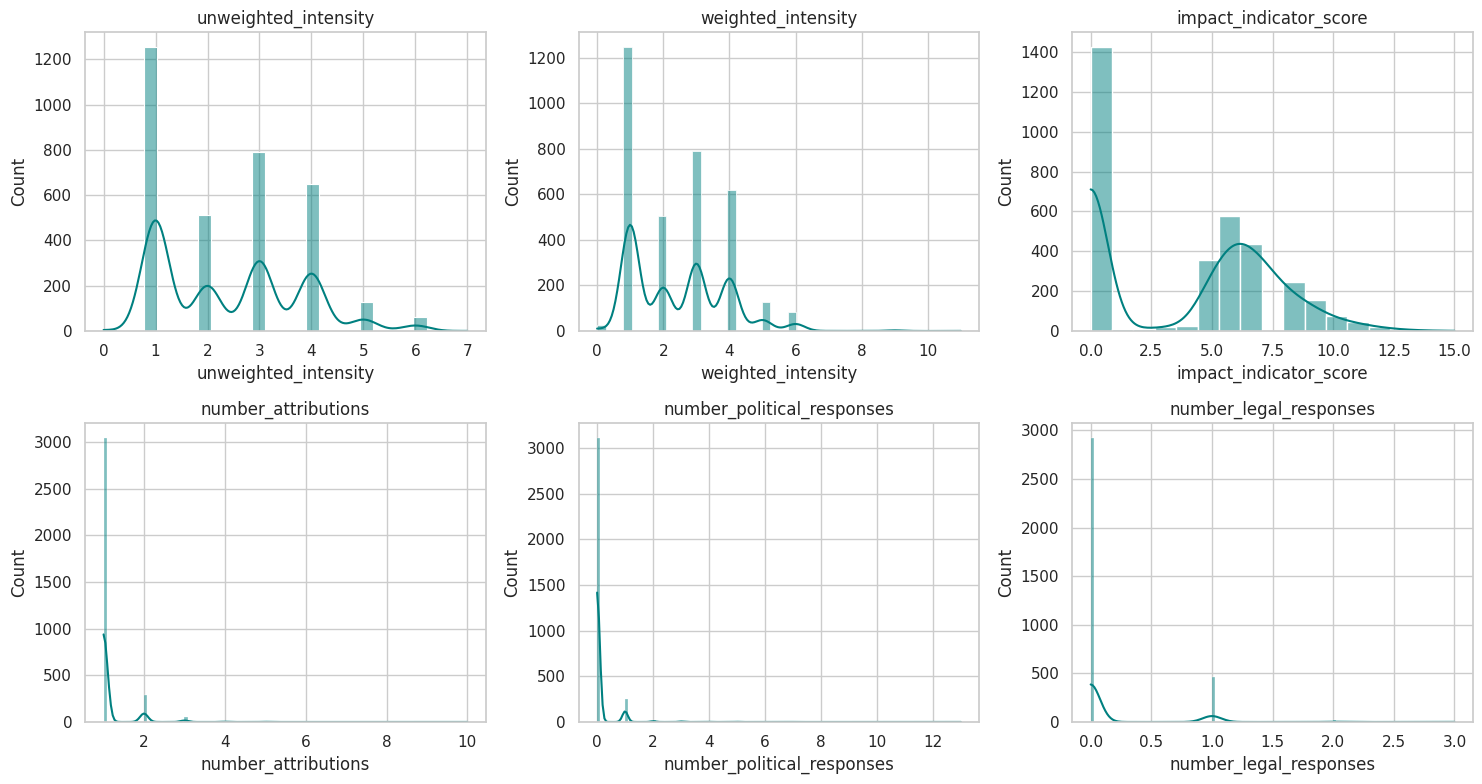

In [ ]:
dist_cols = ["unweighted_intensity", "weighted_intensity", "impact_indicator_score",
             "number_attributions", "number_political_responses", "number_legal_responses"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, dist_cols):
    sns.histplot(global_df[col].dropna(), kde=True, ax=ax, color="teal")
    ax.set_title(col)
plt.tight_layout()
plt.show()


### Understanding the Distribution Plots (Histograms)
These charts show how the 'scores' of incidents are spread out.

**Key Variables Explained:**
- **Intensity (Weighted/Unweighted):** A scale representing how 'severe' or 'loud' a cyber incident was. Higher numbers = more aggressive actions.
- **Impact Indicator Score:** A calculated score (0 to 15) representing the damage caused.
- **Attributions/Responses:** The count of how many times the incident was officially blamed on someone or how many political/legal actions were taken in response.

**How to read the bars:**
- The height of the bar shows how many incidents fall into that specific score range. Most incidents have low scores (the bars are tallest on the left).

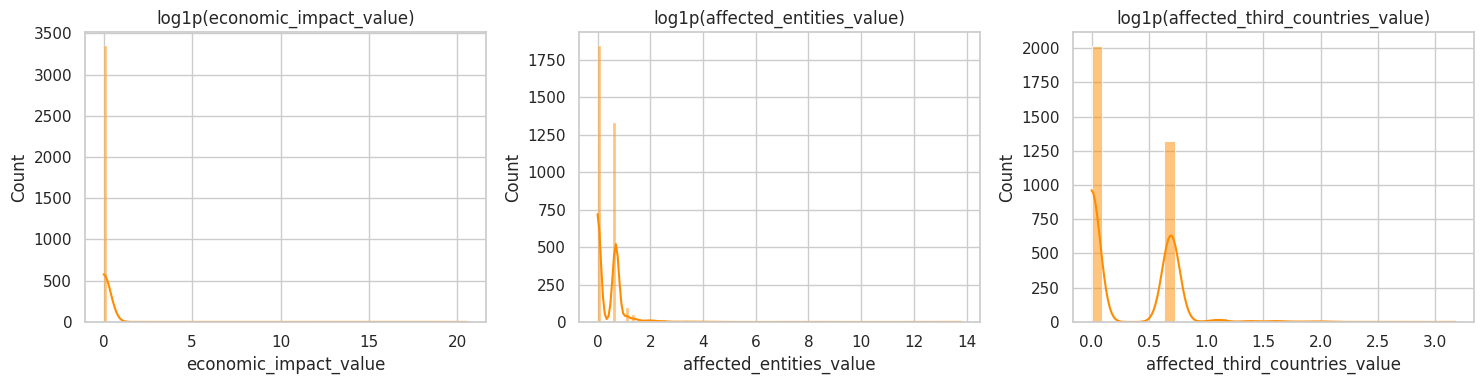

In [ ]:
# Heavily skewed monetary / scale variables -> log1p transform for visualization
skewed_cols = ["economic_impact_value", "affected_entities_value", "affected_third_countries_value"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, skewed_cols):
    vals = np.log1p(global_df[col].dropna())
    sns.histplot(vals, kde=True, ax=ax, color="darkorange")
    ax.set_title(f"log1p({col})")
plt.tight_layout()
plt.show()


### Understanding Log-Scale Plots
Variables like **Economic Impact** (money lost) and **Affected Entities** (number of victims) have a few 'super-incidents' with massive numbers and thousands of 'small' incidents.

**What is 'log1p'?**
- If we used a normal scale, the tiny incidents would be invisible compared to the massive ones. The **log scale** 'squashes' the big numbers so we can see the distribution of all incidents clearly on one graph.

## 5. Outlier detection

Two complementary views:
- **Boxplots** for a visual read of spread and extreme points
- **IQR rule** and **Z-score** to actually flag/count outlier rows per variable

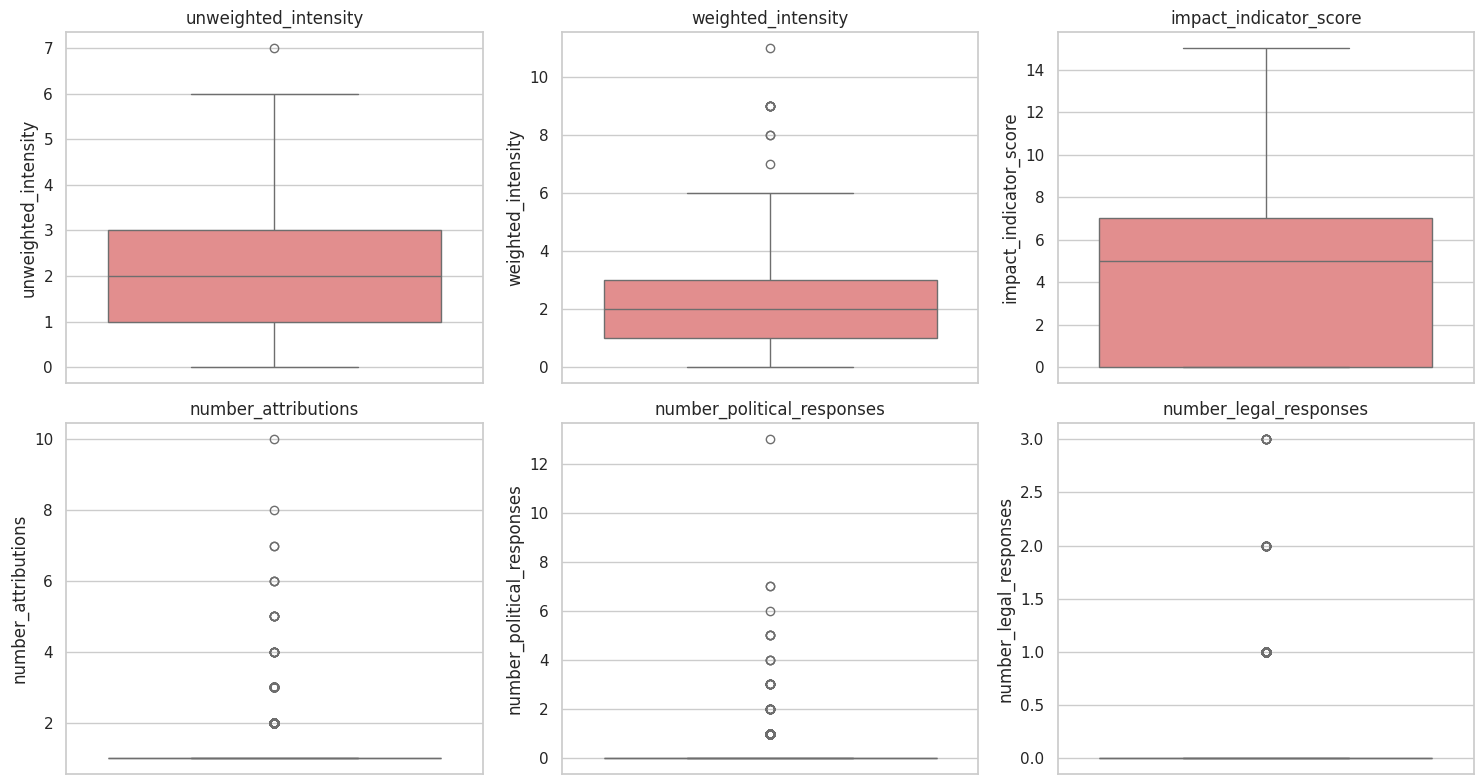

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, dist_cols):
    sns.boxplot(y=global_df[col], ax=ax, color="lightcoral")
    ax.set_title(col)
plt.tight_layout()
plt.show()


### Understanding Boxplots (Outlier Detection)
Boxplots show the 'typical' range of your data and highlight unusual cases.

**How to read a Boxplot:**
- **The Box:** Represents the middle 50% of your data. The line in the middle is the **Median** (the middle value).
- **The 'Whiskers' (Lines):** Show the general range of the data.
- **The Dots:** These are **Outliers**. In cyber security, these represent 'Black Swan' events—incidents that were significantly more severe or had many more responses than a typical attack.

In [ ]:
def iqr_outlier_count(series):
    s = series.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lower) | (s > upper)).sum(), lower, upper

rows = []
for col in numeric_cols:
    n_out, lower, upper = iqr_outlier_count(global_df[col])
    rows.append({"column": col, "n_outliers_iqr": n_out,
                 "pct_outliers": round(100 * n_out / global_df[col].notna().sum(), 2),
                 "lower_bound": lower, "upper_bound": upper})

outlier_summary = pd.DataFrame(rows).sort_values("pct_outliers", ascending=False)
outlier_summary


,column,n_outliers_iqr,pct_outliers,lower_bound,upper_bound
8,number_legal_responses,488,14.29,0.0,0.0
0,number_attributions,366,10.72,1.0,1.0
1,number_political_responses,297,8.70,0.0,0.0
5,affected_entities_value,151,4.42,-1.5,2.5
7,economic_impact_value,70,2.05,0.0,0.0
6,affected_third_countries_value,45,1.32,-1.5,2.5
3,weighted_intensity,11,0.32,-2.0,6.0
2,unweighted_intensity,1,0.03,-2.0,6.0
4,impact_indicator_score,0,0.00,-10.5,17.5


In [ ]:
# Z-score view (|z| > 3) for comparison, on the same columns
z_rows = []
for col in dist_cols + skewed_cols:
    s = global_df[col].dropna()
    z = np.abs(stats.zscore(s))
    z_rows.append({"column": col, "n_outliers_zscore_gt3": int((z > 3).sum())})

pd.DataFrame(z_rows)


,column,n_outliers_zscore_gt3
0,unweighted_intensity,1
1,weighted_intensity,11
2,impact_indicator_score,1
3,number_attributions,72
4,number_political_responses,40
5,number_legal_responses,28
6,economic_impact_value,9
7,affected_entities_value,1
8,affected_third_countries_value,32


## 8. Scatterplots between key numeric variables

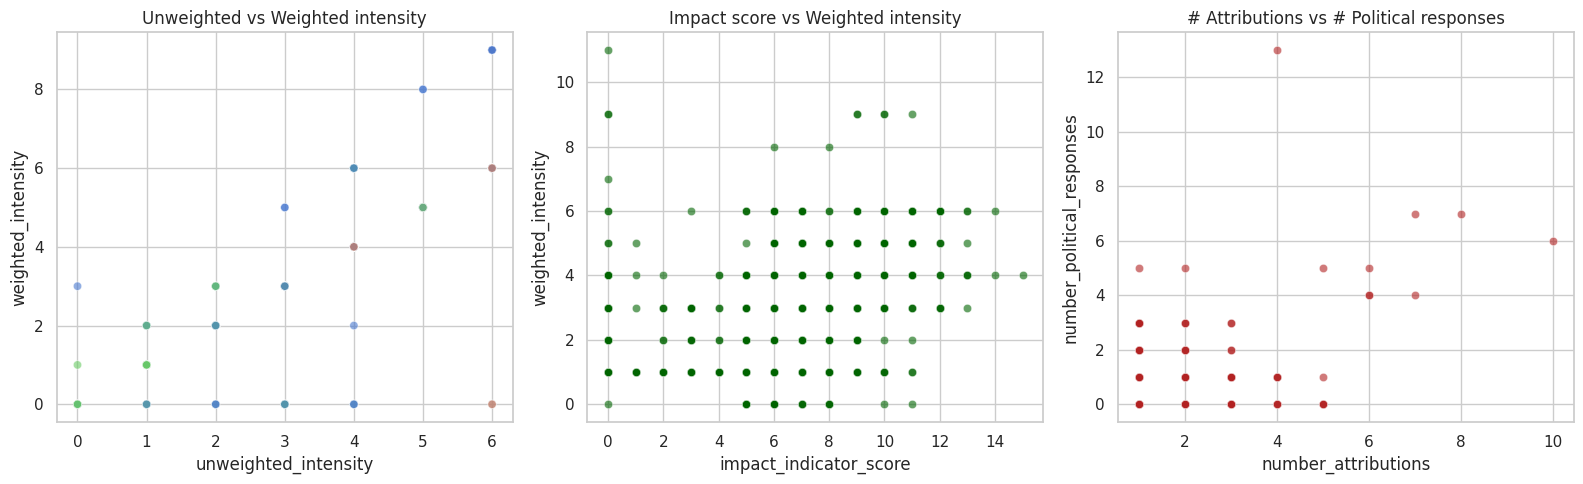

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.scatterplot(data=global_df, x="unweighted_intensity", y="weighted_intensity",
                 hue="impact_indicator_label" if "impact_indicator_label" in global_df.columns else None,
                 ax=axes[0], alpha=0.6, legend=False)
axes[0].set_title("Unweighted vs Weighted intensity")

sns.scatterplot(data=global_df, x="impact_indicator_score", y="weighted_intensity",
                 ax=axes[1], alpha=0.6, color="darkgreen")
axes[1].set_title("Impact score vs Weighted intensity")

sns.scatterplot(data=global_df, x="number_attributions", y="number_political_responses",
                 ax=axes[2], alpha=0.6, color="firebrick")
axes[2].set_title("# Attributions vs # Political responses")

plt.tight_layout()
plt.show()


### Understanding Scatterplots
Scatterplots compare two specific numeric variables directly to see patterns.

- **Plot 1:** Shows the almost perfect line between the two intensity metrics.
- **Plot 3:** Compares **Attributions** (naming the attacker) vs **Political Responses**. It helps us see if states respond more aggressively when they are more certain about who attacked them.

## 9. Pairplot of a small, meaningful subset of columns

Picking a handful of the most interpretable severity/response variables plus one categorical hue,
rather than all 84 columns (which would be unreadable in a pairplot).

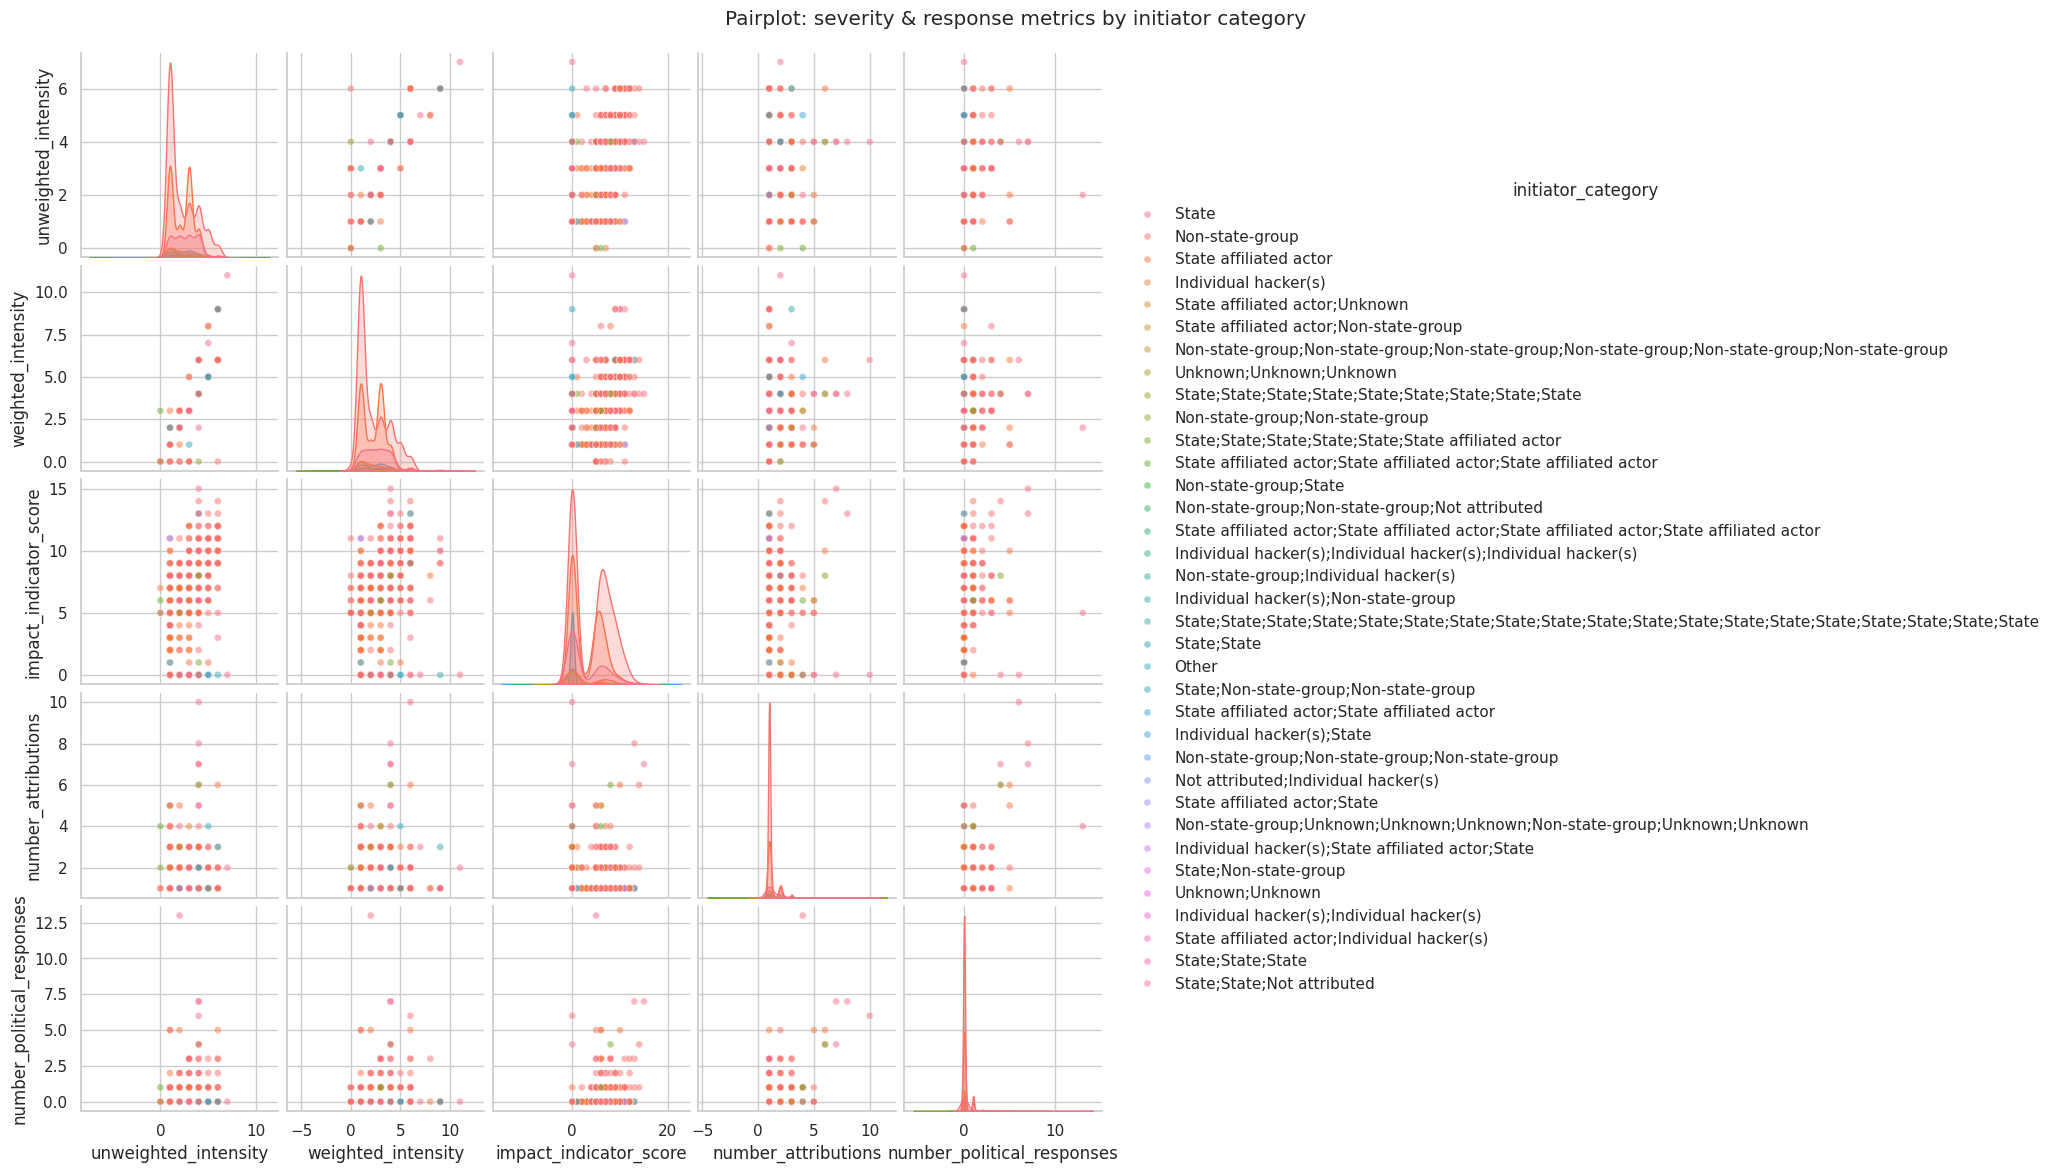

In [ ]:
pairplot_cols = ["unweighted_intensity", "weighted_intensity", "impact_indicator_score",
                  "number_attributions", "number_political_responses"]

pp_df = global_df[pairplot_cols + ["initiator_category"]].dropna(subset=pairplot_cols)

sns.pairplot(pp_df, vars=pairplot_cols, hue="initiator_category",
             diag_kind="kde", plot_kws={"alpha": 0.5, "s": 25}, height=2.3)
plt.suptitle("Pairplot: severity & response metrics by initiator category", y=1.02)
plt.show()


### Understanding the Pairplot
This is a 'Master View' that combines histograms and scatterplots.

- **The Diagonals:** Show the distribution (waves) for each variable.
- **The Colors (Hue):** Each color represents a different **Initiator Category** (State vs. Non-state). This helps you see if 'State' actors behave differently than 'Individual hackers'.

## 10. Quick relationship checks using the dyadic dataset

The dyadic table lets us ask questions like: *do certain initiator categories tend to produce
higher-impact incidents?* or *is there a relationship between operation type and intensity?*

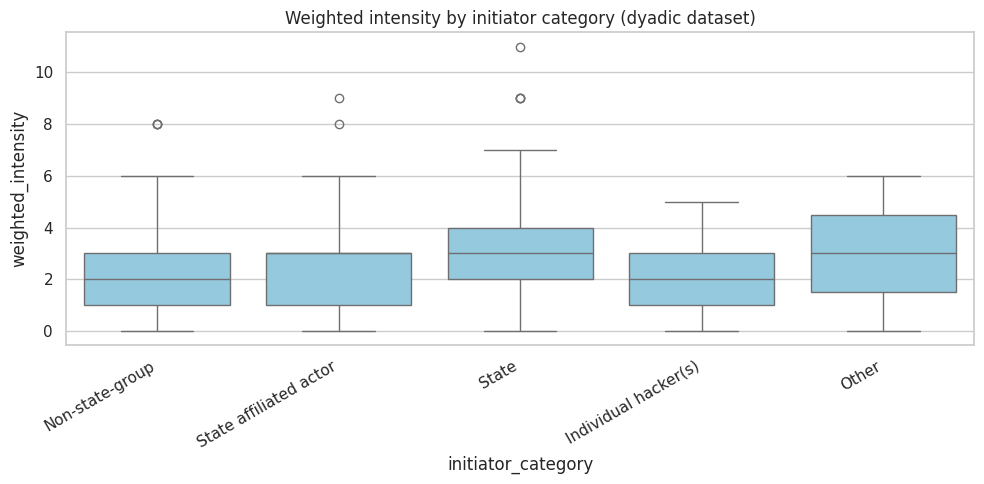

In [ ]:
plt.figure(figsize=(10, 5))
order = dyadic_df["initiator_category"].value_counts().index
sns.boxplot(data=dyadic_df, x="initiator_category", y="weighted_intensity", order=order, color="skyblue")
plt.xticks(rotation=30, ha="right")
plt.title("Weighted intensity by initiator category (dyadic dataset)")
plt.tight_layout()
plt.show()


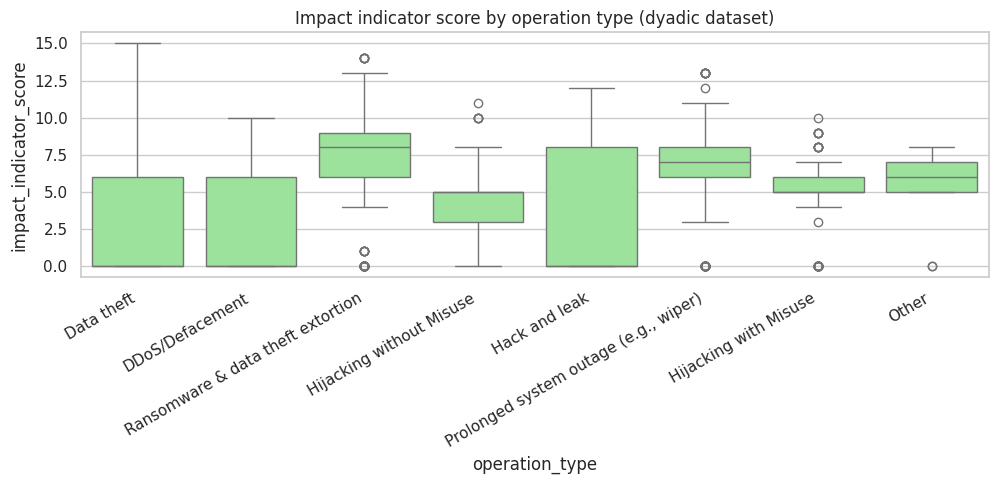

In [ ]:
plt.figure(figsize=(10, 5))
order2 = dyadic_df["operation_type"].value_counts().index
sns.boxplot(data=dyadic_df, x="operation_type", y="impact_indicator_score", order=order2, color="lightgreen")
plt.xticks(rotation=30, ha="right")
plt.title("Impact indicator score by operation type (dyadic dataset)")
plt.tight_layout()
plt.show()


### Understanding Impact by Operation Type
This boxplot answers: *'Which type of attack causes the most damage?'*

**Variable Explained:**
- **Operation Type:** The specific method used (e.g., Ransomware, DDoS, Hack and Leak).
- **Findings:** You can see that **Ransomware & data theft extortion** (the green box positioned higher up) typically results in a higher **Impact Indicator Score** than simple data theft.

In [ ]:
# One-way ANOVA: does impact_indicator_score differ significantly across initiator_category?
groups = [g["impact_indicator_score"].dropna().values
          for _, g in dyadic_df.groupby("initiator_category") if g["impact_indicator_score"].notna().sum() > 1]

f_stat, p_val = stats.f_oneway(*groups)
print(f"One-way ANOVA — impact_indicator_score across initiator_category: F = {f_stat:.3f}, p = {p_val:.4f}")


One-way ANOVA — impact_indicator_score across initiator_category: F = 54.415, p = 0.0000
